# Three-Way Run Comparison — Sept–Oct 187 Articles

Compares per-article classifications across three runs on the same 187-article test set:

| Run | Output | Notes |
| :-- | :-- | :-- |
| **RUN1** | `results_gt_ext200_mapped.csv` (subset to shared 187 ids) | Original extended-context run over the 1,163-article corpus |
| **RUN2** | `results_sept_oct_rel_mapped.csv` | Re-classification with `gt_300.csv` (296 GT rows, 233 labeled) |
| **RUN3** | `results_sept_oct_rel_2_mapped.csv` | Re-classification with `gt_recent.csv` (124 GT rows from Aug-2023+, 118 labeled) |

Since all three CSVs are mapped with `map_intraday.py`, the realized price columns (`pct_5m` … `pct_1d`) and the rolling-SD `true_criticality` label are identical per-id across files. Every difference reflects the classifier, not the data.

Sections:
1. Load & join on `id`
2. Agreement across runs (relevance, criticality, tier, event, direction)
3. DXY-movement range for critical vs not — one panel per run
4. Per-tier and per-event critical-rate breakdown
5. Case-level differences (pairwise + three-way disagreements)
6. Mann-Whitney U tests (within each run + between runs on disagreement slices)
7. Precision / recall vs rolling-SD truth
8. Directional accuracy
9. Headline numbers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.size': 11,
})

TEAL, AMBER, BLUE, CORAL, GRAY = '#1D9E75', '#BA7517', '#378ADD', '#D85A30', '#888780'
RUN_COLOR = {'RUN1': BLUE, 'RUN2': TEAL, 'RUN3': AMBER}

HORIZONS = ['pct_5m', 'pct_15m', 'pct_1h', 'pct_4h', 'pct_1d']
H_LABELS = ['5m', '15m', '1h', '4h', '1d']

RUN_LABELS = {
    'RUN1': 'RUN1 — gt_ext200 (orig)',
    'RUN2': 'RUN2 — gt_300 (296 GT)',
    'RUN3': 'RUN3 — gt_recent (124 GT)',
}

## 1 — Load & join on `id`

RUN1 is subsetted to the 187 shared ids so every row compares the three runs on the same article.

In [2]:
r1_all = pd.read_csv('data/results_gt_ext200_mapped.csv')
r2     = pd.read_csv('data/results_sept_oct_rel_mapped.csv')
r3     = pd.read_csv('data/results_sept_oct_rel_2_mapped.csv')
r1     = r1_all[r1_all['id'].isin(r2['id'])].copy()

print(f'RUN1 (full corpus)         : {len(r1_all)}')
print(f'RUN1 restricted to shared  : {len(r1)}')
print(f'RUN2                       : {len(r2)}')
print(f'RUN3                       : {len(r3)}')

# Classifier columns we want per run (suffixed at join time)
CLASS_COLS = ['is_relevant', 'is_critical', 'content_type', 'event_number',
              'event_name', 'event_tier', 'criticality_level', 'direction',
              'direction_confidence', 'table_used']

# Base rows = r2 with its truth columns (identical across mapped files);
# then join r1 and r3 classifier columns.
base = r2.copy()
base = base.rename(columns={c: f'{c}_r2' for c in CLASS_COLS})
base = base.merge(r1[['id'] + CLASS_COLS].rename(columns={c: f'{c}_r1' for c in CLASS_COLS}), on='id')
base = base.merge(r3[['id'] + CLASS_COLS].rename(columns={c: f'{c}_r3' for c in CLASS_COLS}), on='id')
print(f'\nJoined rows                : {len(base)}')

RUN1 (full corpus)         : 1163
RUN1 restricted to shared  : 187
RUN2                       : 187
RUN3                       : 187

Joined rows                : 187


## 2 — Agreement Across Runs

Pairwise agreement on each categorical field, plus 3-way agreement (all three equal).

In [3]:
fields = ['is_relevant', 'is_critical', 'criticality_level',
          'event_tier', 'event_number', 'content_type', 'direction']

rows = []
for f in fields:
    a, b, c = base[f'{f}_r1'], base[f'{f}_r2'], base[f'{f}_r3']
    n_all  = base[[f'{f}_r1', f'{f}_r2', f'{f}_r3']].dropna().shape[0]
    all_eq = ((a == b) & (b == c)).sum()
    rows.append({
        'field': f,
        'n (all 3 labeled)': n_all,
        'RUN1=RUN2': int((a == b).sum()),
        'RUN1=RUN3': int((a == c).sum()),
        'RUN2=RUN3': int((b == c).sum()),
        'all 3 agree': int(all_eq),
        'all-3 rate': f'{all_eq/len(base)*100:.1f}%',
    })
display(pd.DataFrame(rows).set_index('field'))

,n (all 3 labeled),RUN1=RUN2,RUN1=RUN3,RUN2=RUN3,all 3 agree,all-3 rate
field,,,,,,
is_relevant,187,176,165,174,164,87.7%
is_critical,187,163,166,172,157,84.0%
criticality_level,164,152,144,149,134,71.7%
event_tier,164,160,151,149,144,77.0%
event_number,187,151,135,146,126,67.4%
content_type,187,163,160,172,154,82.4%
direction,164,135,120,130,107,57.2%


In [4]:
summary = pd.DataFrame({
    'RUN1': [base['is_relevant_r1'].sum(), base['is_critical_r1'].sum(),
             (base['criticality_level_r1'] == 'high').sum(),
             (base['criticality_level_r1'] == 'not high').sum()],
    'RUN2': [base['is_relevant_r2'].sum(), base['is_critical_r2'].sum(),
             (base['criticality_level_r2'] == 'high').sum(),
             (base['criticality_level_r2'] == 'not high').sum()],
    'RUN3': [base['is_relevant_r3'].sum(), base['is_critical_r3'].sum(),
             (base['criticality_level_r3'] == 'high').sum(),
             (base['criticality_level_r3'] == 'not high').sum()],
}, index=['relevant', 'critical (flag)',
          'criticality_level=high', 'criticality_level=not high'])
print('Counts across the 187 shared articles:')
display(summary)

print('\nCriticality overlap:')
print(f'  All 3 critical       : {int((base["is_critical_r1"] & base["is_critical_r2"] & base["is_critical_r3"]).sum())}')
print(f'  All 3 not critical   : {int((~base["is_critical_r1"] & ~base["is_critical_r2"] & ~base["is_critical_r3"]).sum())}')
print(f'  Exactly 2 critical   : {int((base[["is_critical_r1","is_critical_r2","is_critical_r3"]].sum(axis=1) == 2).sum())}')
print(f'  Exactly 1 critical   : {int((base[["is_critical_r1","is_critical_r2","is_critical_r3"]].sum(axis=1) == 1).sum())}')

Counts across the 187 shared articles:


,RUN1,RUN2,RUN3
relevant,187,176,165
critical (flag),39,31,20
criticality_level=high,39,31,20
criticality_level=not high,148,145,145



Criticality overlap:
  All 3 critical       : 17
  All 3 not critical   : 140
  Exactly 2 critical   : 9
  Exactly 1 critical   : 21


## 3 — DXY Movement Range: Critical vs Not Critical

One panel per run. Since the realized DXY columns are identical across runs, we're isolating how each run's critical flag partitions the same set of moves.

In [5]:
def summary_by_flag(df, flag_col):
    rows = []
    for is_crit, label in [(True, 'critical'), (False, 'not critical')]:
        g = df[df[flag_col] == is_crit]
        row = {'flag': label, 'n': len(g)}
        for h in HORIZONS:
            vals = g[h].abs().dropna()
            row[f'|{h}| mean'] = round(vals.mean(), 5) if len(vals) else np.nan
            row[f'|{h}| med']  = round(vals.median(), 5) if len(vals) else np.nan
            row[f'|{h}| max']  = round(vals.max(), 5) if len(vals) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('flag')

for tag, col in [('RUN1', 'is_critical_r1'), ('RUN2', 'is_critical_r2'), ('RUN3', 'is_critical_r3')]:
    print(f'\n{tag} — {RUN_LABELS[tag]}:')
    display(summary_by_flag(base, col))


RUN1 — RUN1 — gt_ext200 (orig):


,n,|pct_5m| mean,|pct_5m| med,|pct_5m| max,|pct_15m| mean,|pct_15m| med,|pct_15m| max,|pct_1h| mean,|pct_1h| med,|pct_1h| max,|pct_4h| mean,|pct_4h| med,|pct_4h| max,|pct_1d| mean,|pct_1d| med,|pct_1d| max
flag,,,,,,,,,,,,,,,,
critical,39,0.03564,0.02045,0.26893,0.06446,0.03062,0.39438,0.09901,0.07074,0.43527,0.15469,0.14316,0.49025,0.33465,0.28135,0.74906
not critical,148,0.01534,0.01021,0.08305,0.02785,0.02037,0.18367,0.05732,0.04053,0.53981,0.11933,0.08078,0.66047,0.28122,0.23111,1.06924



RUN2 — RUN2 — gt_300 (296 GT):


,n,|pct_5m| mean,|pct_5m| med,|pct_5m| max,|pct_15m| mean,|pct_15m| med,|pct_15m| max,|pct_1h| mean,|pct_1h| med,|pct_1h| max,|pct_4h| mean,|pct_4h| med,|pct_4h| max,|pct_1d| mean,|pct_1d| med,|pct_1d| max
flag,,,,,,,,,,,,,,,,
critical,31,0.04089,0.03049,0.26893,0.05976,0.03039,0.39438,0.09226,0.07071,0.43527,0.1770,0.16355,0.54165,0.31084,0.22539,0.74906
not critical,156,0.01524,0.01021,0.08305,0.03069,0.02044,0.34726,0.06093,0.04074,0.53981,0.1166,0.07197,0.66047,0.28808,0.25388,1.06924



RUN3 — RUN3 — gt_recent (124 GT):


,n,|pct_5m| mean,|pct_5m| med,|pct_5m| max,|pct_15m| mean,|pct_15m| med,|pct_15m| max,|pct_1h| mean,|pct_1h| med,|pct_1h| max,|pct_4h| mean,|pct_4h| med,|pct_4h| max,|pct_1d| mean,|pct_1d| med,|pct_1d| max
flag,,,,,,,,,,,,,,,,
critical,20,0.04794,0.03066,0.26893,0.07798,0.05043,0.34726,0.09760,0.06059,0.43527,0.19709,0.1871,0.54165,0.36303,0.33798,0.74906
not critical,167,0.01622,0.01021,0.08305,0.03051,0.02043,0.39438,0.06257,0.04080,0.53981,0.11791,0.0809,0.66047,0.28370,0.23925,1.06924


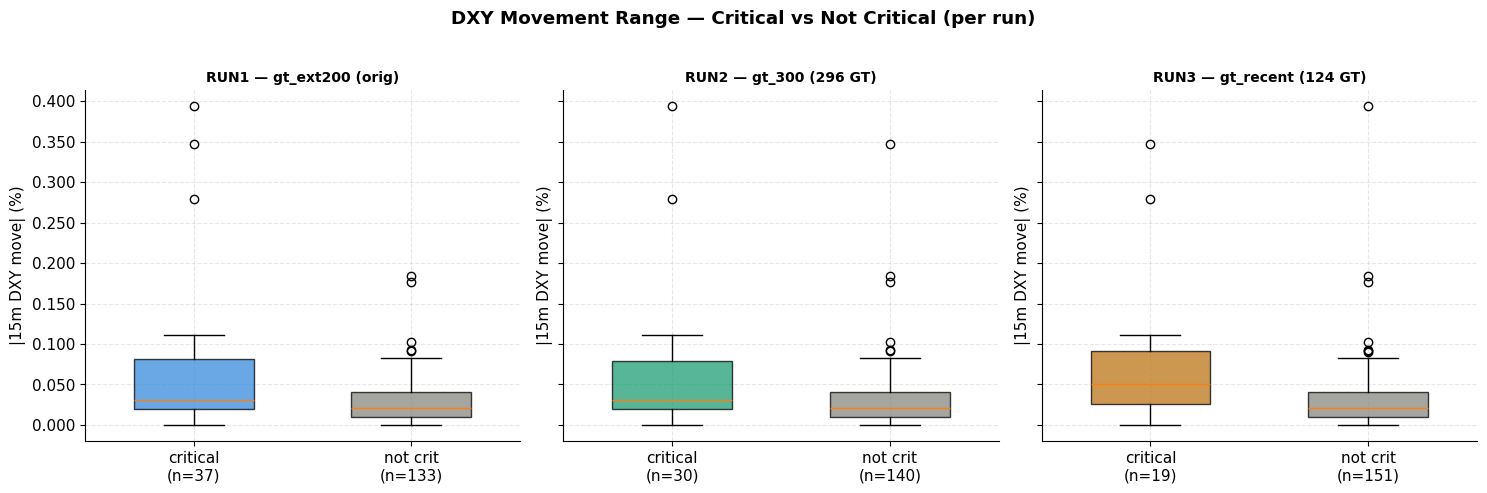

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, (tag, col) in zip(axes, [('RUN1','is_critical_r1'), ('RUN2','is_critical_r2'), ('RUN3','is_critical_r3')]):
    crit = base.loc[base[col] == True,  'pct_15m'].abs().dropna()
    notc = base.loc[base[col] == False, 'pct_15m'].abs().dropna()
    bp = ax.boxplot([crit, notc],
                    labels=[f'critical\n(n={len(crit)})', f'not crit\n(n={len(notc)})'],
                    patch_artist=True, showfliers=True, widths=0.55)
    for patch, color in zip(bp['boxes'], [RUN_COLOR[tag], GRAY]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(RUN_LABELS[tag], fontweight='bold', fontsize=10)
    ax.set_ylabel('|15m DXY move| (%)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.3f}'))
plt.suptitle('DXY Movement Range — Critical vs Not Critical (per run)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

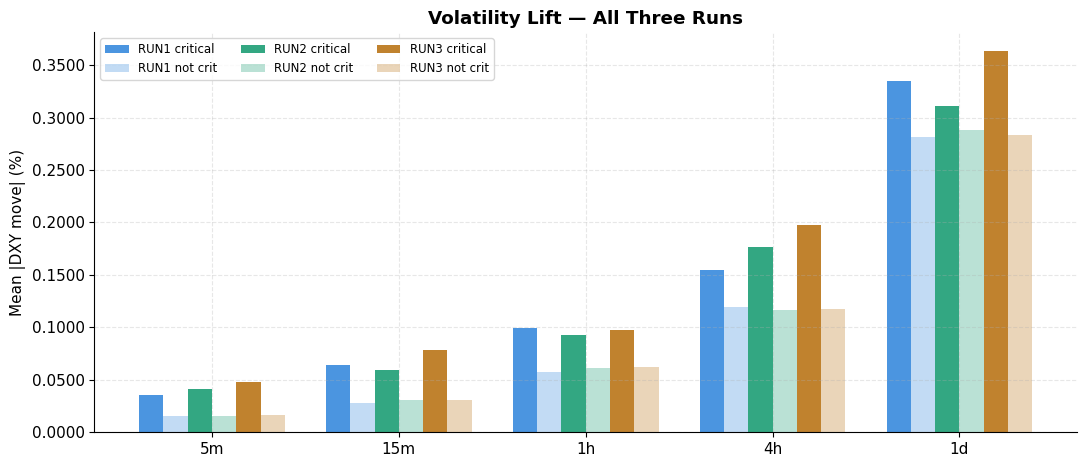


Lift (critical / not-critical) mean |move|:


,RUN1,RUN2,RUN3
horizon,,,
5m,2.32x,2.68x,2.96x
15m,2.31x,1.95x,2.56x
1h,1.73x,1.51x,1.56x
4h,1.30x,1.52x,1.67x
1d,1.19x,1.08x,1.28x


In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(HORIZONS)); w = 0.13

for i, (tag, col) in enumerate([('RUN1','is_critical_r1'), ('RUN2','is_critical_r2'), ('RUN3','is_critical_r3')]):
    h_means = [base.loc[base[col]==True, h].abs().mean() for h in HORIZONS]
    n_means = [base.loc[base[col]==False, h].abs().mean() for h in HORIZONS]
    offset = (i - 1) * 2 * w
    ax.bar(x + offset - w/2, h_means, w, color=RUN_COLOR[tag], alpha=0.9, label=f'{tag} critical')
    ax.bar(x + offset + w/2, n_means, w, color=RUN_COLOR[tag], alpha=0.3, label=f'{tag} not crit')

ax.set_xticks(x); ax.set_xticklabels(H_LABELS)
ax.set_ylabel('Mean |DXY move| (%)')
ax.set_title('Volatility Lift — All Three Runs', fontweight='bold')
ax.legend(ncol=3, fontsize=8.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.4f}'))
plt.tight_layout()
plt.show()

print('\nLift (critical / not-critical) mean |move|:')
lift_rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    row = {'horizon': hl}
    for tag, col in [('RUN1','is_critical_r1'), ('RUN2','is_critical_r2'), ('RUN3','is_critical_r3')]:
        crit = base.loc[base[col]==True,  h].abs().mean()
        notc = base.loc[base[col]==False, h].abs().mean()
        row[tag] = f'{crit/notc:.2f}x' if notc else 'n/a'
    lift_rows.append(row)
display(pd.DataFrame(lift_rows).set_index('horizon'))

## 4 — Per-Tier and Per-Event Breakdown

,RUN1 n,RUN1 crit,RUN1 rate,RUN2 n,RUN2 crit,RUN2 rate,RUN3 n,RUN3 crit,RUN3 rate
tier,,,,,,,,,
T1,56,29,52%,58,17,29%,47,13,28%
T2,11,3,27%,11,3,27%,15,1,7%
T3,65,6,9%,68,8,12%,63,4,6%
T4,55,1,2%,39,3,8%,40,2,5%


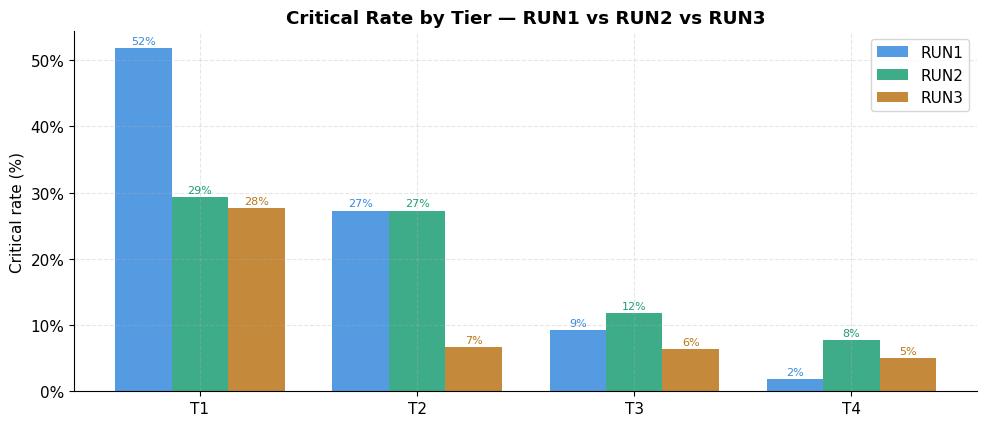

In [8]:
tiers = sorted(set(base['event_tier_r1'].dropna().unique()) |
               set(base['event_tier_r2'].dropna().unique()) |
               set(base['event_tier_r3'].dropna().unique()))
tiers = [int(t) for t in tiers]

tier_rows = []
for t in tiers:
    row = {'tier': f'T{t}'}
    for tag, tcol, ccol in [
        ('RUN1','event_tier_r1','is_critical_r1'),
        ('RUN2','event_tier_r2','is_critical_r2'),
        ('RUN3','event_tier_r3','is_critical_r3'),
    ]:
        g = base[base[tcol] == t]
        n = len(g); nc = int(g[ccol].sum())
        row[f'{tag} n']    = n
        row[f'{tag} crit'] = nc
        row[f'{tag} rate'] = f'{nc/n*100:.0f}%' if n else 'n/a'
    tier_rows.append(row)
display(pd.DataFrame(tier_rows).set_index('tier'))

# Critical rate by tier -- grouped bars
fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(len(tiers)); w = 0.26
for i, (tag, tcol, ccol) in enumerate([
    ('RUN1','event_tier_r1','is_critical_r1'),
    ('RUN2','event_tier_r2','is_critical_r2'),
    ('RUN3','event_tier_r3','is_critical_r3'),
]):
    rates = []
    for t in tiers:
        g = base[base[tcol] == t]
        rates.append(g[ccol].mean()*100 if len(g) else 0)
    offset = (i - 1) * w
    ax.bar(x + offset, rates, w, color=RUN_COLOR[tag], alpha=0.85, label=tag)
    for j, r in enumerate(rates):
        ax.text(j + offset, r + 0.7, f'{r:.0f}%', ha='center', fontsize=8, color=RUN_COLOR[tag])
ax.set_xticks(x); ax.set_xticklabels([f'T{t}' for t in tiers])
ax.set_ylabel('Critical rate (%)'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Critical Rate by Tier — RUN1 vs RUN2 vs RUN3', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Per-event critical rate across runs
events = sorted(set(base['event_number_r1'].dropna().unique()) |
                set(base['event_number_r2'].dropna().unique()) |
                set(base['event_number_r3'].dropna().unique()))

ev_rows = []
for e in events:
    row = {'event': int(e)}
    # event name lookup from whichever run has this row
    for ncol, ecol in [('event_name_r1','event_number_r1'),
                       ('event_name_r2','event_number_r2'),
                       ('event_name_r3','event_number_r3')]:
        match = base.loc[base[ecol] == e, ncol]
        if len(match):
            row['name'] = match.iloc[0]
            break
    for tag, ecol, ccol in [
        ('RUN1','event_number_r1','is_critical_r1'),
        ('RUN2','event_number_r2','is_critical_r2'),
        ('RUN3','event_number_r3','is_critical_r3'),
    ]:
        g = base[base[ecol] == e]
        n = len(g); nc = int(g[ccol].sum())
        row[f'{tag} n']    = n
        row[f'{tag} crit'] = nc
    ev_rows.append(row)
display(pd.DataFrame(ev_rows).set_index('event'))

,name,RUN1 n,RUN1 crit,RUN2 n,RUN2 crit,RUN3 n,RUN3 crit
event,,,,,,,
0,Irrelevant,0,0,11,0,22,0
2,Fed Rate Cut,8,6,8,2,9,2
3,Hawkish Pivot / Surprise,4,3,4,2,4,2
4,Dovish Pivot / Surprise,1,0,1,0,0,0
7,CPI/PCE Above Consensus,4,2,4,2,4,1
8,CPI/PCE Below Consensus,5,4,7,2,5,2
9,Inflation In-Line,2,0,1,0,3,0
10,NFP/Jobs Beat,1,0,1,0,1,0
11,NFP/Jobs Miss,10,10,12,4,12,5


## 5 — Case-Level Differences

Which specific articles did each run handle differently?

In [10]:
# Relevance differences
rel_diff = base[
    (base['is_relevant_r1'] != base['is_relevant_r2']) |
    (base['is_relevant_r2'] != base['is_relevant_r3'])
]
print(f'Relevance disagreement: {len(rel_diff)} articles')
if len(rel_diff):
    display(rel_diff[['id', 'title',
                      'is_relevant_r1', 'is_relevant_r2', 'is_relevant_r3',
                      'event_name_r1', 'event_name_r2', 'event_name_r3']].head(25))

Relevance disagreement: 23 articles


,id,title,is_relevant_r1,is_relevant_r2,is_relevant_r3,event_name_r1,event_name_r2,event_name_r3
5,1aa1e9188e286fd92e279cdec80cf86145f30376a326a8...,CNBC's The China Connection newsletter: Five t...,True,True,False,Other / Mixed,Other / Mixed,Irrelevant
7,2c80f37cc228bd70aca8045d33c58c5777a856d29e6024...,"Gold gains as Fed trims rates, investors asses...",True,False,False,Other / Mixed,Irrelevant,Irrelevant
9,2ca0797077d874af8e888a8061ab581b3739b4bb3a058a...,CNBC Daily Open: A Trump post drowns out posit...,True,False,False,Other / Mixed,Irrelevant,Irrelevant
10,3b18dbe88189dd624517eca2bb7063d087b135437c1c2b...,"'Cockroach' hunting, Bolton indicted, Apple ey...",True,False,False,Other / Mixed,Irrelevant,Irrelevant
41,b06e7d936f638744035986e8cd4987e6bcea12477baa9f...,"Gold slips 1% on rate cut uncertainty, set for...",True,False,False,Fed Rate Path Repricing,Irrelevant,Irrelevant
62,0029859aa2cf7628dc46796585f1f52ac8f9a1874f7903...,Labor Department watchdog opens probe of BLS j...,True,True,False,Other / Mixed,Legal/Judicial Event Affecting Economic Policy,Irrelevant
64,01ad92fc5aaec69938d067d49a373ac8b61ddcee7655d8...,Trump's Fed pressure campaign will lead to hig...,True,False,False,Fed Rate Path Repricing,Irrelevant,Irrelevant
73,0dc6d83294dfb52656785448c0c390cebf1a42095f82d0...,India urges BRICS to tackle deficits as bloc r...,True,False,False,Other / Mixed,Irrelevant,Irrelevant
80,22190fae4d3befec24170ea4aeba360628fd67359e9d25...,CNBC Daily Open: U.S. inflation report on Frid...,True,True,False,Other / Mixed,Other / Mixed,Irrelevant
83,2ba078e1ccb1aba4feff7fac4878f9632ecfad49058aaf...,U.S. warns of response to 'witch hunt' after B...,True,True,False,Other / Mixed,Other / Mixed,Irrelevant


In [11]:
# Criticality differences — categorise by which runs flagged critical
def crit_pattern(row):
    flags = [row['is_critical_r1'], row['is_critical_r2'], row['is_critical_r3']]
    return '-'.join('C' if f else '.' for f in flags)

base['crit_pat'] = base.apply(crit_pattern, axis=1)
print('Criticality pattern (R1-R2-R3, C=critical, .=not):')
print(base['crit_pat'].value_counts())

# Show all rows where patterns diverge (any disagreement)
divergent = base[base['crit_pat'].isin(['C-C-.','C-.-C','.-C-C','C-.-.','.-C-.','.-.-C'])]
print(f'\nTotal divergent rows: {len(divergent)}')

Criticality pattern (R1-R2-R3, C=critical, .=not):
crit_pat
.-.-.    140
C-C-C     17
C-.-.     14
.-C-.      7
C-C-.      6
C-.-C      2
.-C-C      1
Name: count, dtype: int64

Total divergent rows: 30


In [12]:
# Show the two most interesting slices
cols = ['title', 'crit_pat',
        'event_name_r1', 'event_name_r2', 'event_name_r3',
        'pct_15m', 'true_criticality']

# Only RUN1 critical
only_r1 = divergent[divergent['crit_pat'] == 'C-.-.']
print(f'Only RUN1 flagged critical (n={len(only_r1)}):')
display(only_r1[cols].head(10))

# Only RUN3 critical
only_r3 = divergent[divergent['crit_pat'] == '.-.-C']
print(f'\nOnly RUN3 flagged critical (n={len(only_r3)}):')
display(only_r3[cols].head(10))

# RUN2 and RUN3 agree, RUN1 differs
r2r3_only = divergent[divergent['crit_pat'] == '.-C-C']
print(f'\nRUN2+RUN3 critical, RUN1 not (n={len(r2r3_only)}):')
display(r2r3_only[cols].head(10))

Only RUN1 flagged critical (n=14):


,title,crit_pat,event_name_r1,event_name_r2,event_name_r3,pct_15m,true_criticality
0,Why Gold Price Drops Despite Fed Rate Cut — Oc...,C-.-.,Fed Rate Cut,Fed Rate Cut,Fed Rate Cut,0.070693,high
4,CNBC Daily Open: Bad loans by regional banks s...,C-.-.,US Banking / Financial System Stress,Other / Mixed,US Banking / Financial System Stress,0.040733,high
21,CNBC Daily Open: Cooler-than-expected U.S. con...,C-.-.,CPI/PCE Below Consensus,CPI/PCE Below Consensus,CPI/PCE Below Consensus,NaN,NaN
22,"Trump says fentanyl tariff cut, 'farmers,' Nvi...",C-.-.,Trade Policy Escalation Signal,Executive Policy Signal,Executive Policy Signal,0.020255,not high
24,What this Fed rate cut means for your credit c...,C-.-.,Fed Rate Cut,Fed Rate Cut,Fed Rate Cut,0.010115,not high
75,Mortgage rates see biggest one-day drop in ove...,C-.-.,NFP/Jobs Miss,NFP/Jobs Miss,NFP/Jobs Miss,0.081976,high
79,10-year Treasury yield falls on surprise decli...,C-.-.,CPI/PCE Below Consensus,CPI/PCE Below Consensus,CPI/PCE Below Consensus,0.020448,not high
92,U.S. economy is worse than thought with 1.2 mi...,C-.-.,Fed Rate Path Repricing,NFP/Jobs Miss,NFP/Jobs Miss,0.020469,not high
96,10-year Treasury yield slides to lowest level ...,C-.-.,NFP/Jobs Miss,NFP/Jobs Miss,NFP/Jobs Miss,-0.030618,high
107,CNBC Daily Open: U.S. jobs report in August re...,C-.-.,NFP/Jobs Miss,NFP/Jobs Miss,NFP/Jobs Miss,-0.020450,not high



Only RUN3 flagged critical (n=0):


,title,crit_pat,event_name_r1,event_name_r2,event_name_r3,pct_15m,true_criticality



RUN2+RUN3 critical, RUN1 not (n=1):


,title,crit_pat,event_name_r1,event_name_r2,event_name_r3,pct_15m,true_criticality
74,European markets tumble; British pound drops 1...,.-C-C,Other / Mixed,Other / Mixed,Other / Mixed,0.020439,not high


In [13]:
# Pairwise tier confusion matrices (where both runs classified)
def tier_ct(df, a_col, b_col, a_lab, b_lab):
    s = df.dropna(subset=[a_col, b_col])
    return pd.crosstab(s[a_col].astype(int), s[b_col].astype(int),
                       rownames=[a_lab], colnames=[b_lab], margins=True)

print('RUN1 tier × RUN2 tier:')
display(tier_ct(base, 'event_tier_r1', 'event_tier_r2', 'RUN1', 'RUN2'))
print('\nRUN1 tier × RUN3 tier:')
display(tier_ct(base, 'event_tier_r1', 'event_tier_r3', 'RUN1', 'RUN3'))
print('\nRUN2 tier × RUN3 tier:')
display(tier_ct(base, 'event_tier_r2', 'event_tier_r3', 'RUN2', 'RUN3'))

RUN1 tier × RUN2 tier:


RUN2,1,2,3,4,All
RUN1,,,,,
1,52,0,0,0,52
2,1,9,0,1,11
3,0,0,63,2,65
4,5,2,5,36,48
All,58,11,68,39,176



RUN1 tier × RUN3 tier:


RUN3,1,2,3,4,All
RUN1,,,,,
1,45,1,0,6,52
2,0,11,0,0,11
3,0,0,62,1,63
4,2,3,1,33,39
All,47,15,63,40,165



RUN2 tier × RUN3 tier:


RUN3,1,2,3,4,All
RUN2,,,,,
1,47,2,0,7,56
2,0,10,0,0,10
3,0,0,62,2,64
4,0,3,1,30,34
All,47,15,63,39,164


In [14]:
# Direction disagreement where all three returned up/down
all_dir = base[base['direction_r1'].isin(['up','down']) &
               base['direction_r2'].isin(['up','down']) &
               base['direction_r3'].isin(['up','down'])]

diff_dir = all_dir[(all_dir['direction_r1'] != all_dir['direction_r2']) |
                   (all_dir['direction_r2'] != all_dir['direction_r3'])]
print(f'Direction disagreement (all 3 labeled): {len(diff_dir)}/{len(all_dir)} articles')
if len(diff_dir):
    display(diff_dir[['title', 'direction_r1', 'direction_r2', 'direction_r3',
                      'pct_15m', 'true_direction']].head(15))

Direction disagreement (all 3 labeled): 11/79 articles


,title,direction_r1,direction_r2,direction_r3,pct_15m,true_direction
4,CNBC Daily Open: Bad loans by regional banks s...,up,down,down,0.040733,up
21,CNBC Daily Open: Cooler-than-expected U.S. con...,down,down,up,NaN,NaN
26,"U.S. and China talks sketch out rare earths, t...",up,down,down,NaN,NaN
30,Here are the five key takeaways from the Fed m...,up,down,up,0.000000,down
48,Repo Market’s Warning Light is Flickering - Th...,down,down,up,0.000000,down
59,‘The tide went out’: How a string of bad loans...,up,up,down,0.000000,down
74,European markets tumble; British pound drops 1...,down,up,up,0.020439,up
121,Fed approves quarter-point interest rate cut a...,down,down,up,-0.279272,down
157,"From bananas to toys, these 5 charts show how ...",up,down,down,NaN,NaN
174,Cleveland Fed’s Hammack warns of 'challenging ...,up,up,down,0.000000,down


## 6 — Mann-Whitney U Tests

1. Within each run: does the critical flag separate larger moves from smaller moves?
2. Between runs on the disagreement slice: does "only run X" have a different distribution of |pct_15m| than the runs that disagreed?

In [15]:
def mw_within(df, flag_col):
    rows = []
    for h, hl in zip(HORIZONS, H_LABELS):
        hv  = df.loc[df[flag_col] == True,  h].abs().dropna()
        nhv = df.loc[df[flag_col] == False, h].abs().dropna()
        if len(hv) == 0 or len(nhv) == 0:
            continue
        _, p = mannwhitneyu(hv, nhv, alternative='greater')
        rows.append({'horizon': hl, 'n crit': len(hv), 'n not': len(nhv),
                     'mean |crit|': round(hv.mean(), 5),
                     'mean |not|':  round(nhv.mean(), 5),
                     'lift': f'{hv.mean()/nhv.mean():.2f}x',
                     'p-value': f'{p:.4f}',
                     'sig': 'Y' if p < 0.05 else 'N'})
    return pd.DataFrame(rows).set_index('horizon')

for tag, col in [('RUN1','is_critical_r1'), ('RUN2','is_critical_r2'), ('RUN3','is_critical_r3')]:
    print(f'\n{tag} — {RUN_LABELS[tag]} (one-sided, alt=greater):')
    display(mw_within(base, col))


RUN1 — RUN1 — gt_ext200 (orig) (one-sided, alt=greater):


,n crit,n not,mean |crit|,mean |not|,lift,p-value,sig
horizon,,,,,,,
5m,37,133,0.03564,0.01534,2.32x,0.0003,Y
15m,37,133,0.06446,0.02785,2.31x,0.0020,Y
1h,37,130,0.09901,0.05732,1.73x,0.0026,Y
4h,34,123,0.15469,0.11933,1.30x,0.0449,Y
1d,27,107,0.33465,0.28122,1.19x,0.0976,N



RUN2 — RUN2 — gt_300 (296 GT) (one-sided, alt=greater):


,n crit,n not,mean |crit|,mean |not|,lift,p-value,sig
horizon,,,,,,,
5m,30,140,0.04089,0.01524,2.68x,0.0002,Y
15m,30,140,0.05976,0.03069,1.95x,0.0161,Y
1h,30,137,0.09226,0.06093,1.51x,0.0138,Y
4h,27,130,0.17700,0.11660,1.52x,0.0040,Y
1d,23,111,0.31084,0.28808,1.08x,0.2987,N



RUN3 — RUN3 — gt_recent (124 GT) (one-sided, alt=greater):


,n crit,n not,mean |crit|,mean |not|,lift,p-value,sig
horizon,,,,,,,
5m,19,151,0.04794,0.01622,2.96x,0.0001,Y
15m,19,151,0.07798,0.03051,2.56x,0.0011,Y
1h,19,148,0.09760,0.06257,1.56x,0.0399,Y
4h,18,139,0.19709,0.11791,1.67x,0.0238,Y
1d,14,120,0.36303,0.28370,1.28x,0.0824,N


In [16]:
# Slice |pct_15m| by crit_pat and MW-test pairs that look interesting
patterns = ['C-C-C', '.-.-.',
            'C-C-.', 'C-.-C', '.-C-C',
            'C-.-.', '.-C-.', '.-.-C']

grp_moves = {}
for pat in patterns:
    g = base[base['crit_pat'] == pat]['pct_15m'].abs().dropna()
    grp_moves[pat] = g

rows = []
for pat in patterns:
    g = grp_moves[pat]
    rows.append({
        'pattern': pat,
        'meaning': {
            'C-C-C':'all 3 crit', '.-.-.':'none crit',
            'C-C-.':'RUN1+2 crit', 'C-.-C':'RUN1+3 crit', '.-C-C':'RUN2+3 crit',
            'C-.-.':'only RUN1',   '.-C-.':'only RUN2',   '.-.-C':'only RUN3',
        }[pat],
        'n': len(g),
        'mean |15m|': f'{g.mean():.5f}' if len(g) else 'n/a',
        'median |15m|': f'{g.median():.5f}' if len(g) else 'n/a',
    })
display(pd.DataFrame(rows).set_index('pattern'))

def mw_pair(a, b, alt='two-sided'):
    if len(a) == 0 or len(b) == 0: return None
    _, p = mannwhitneyu(a, b, alternative=alt)
    return p

print('\nMW two-sided — between disagreement groups:')
pairs = [('C-.-.', '.-.-C'), ('C-.-.', '.-C-.'), ('.-C-.', '.-.-C'),
         ('C-C-.', '.-C-C'), ('C-C-C', '.-.-.')]
for a_pat, b_pat in pairs:
    p = mw_pair(grp_moves[a_pat], grp_moves[b_pat])
    if p is None:
        print(f'  {a_pat} vs {b_pat}: insufficient data')
    else:
        print(f'  {a_pat} vs {b_pat}: p = {p:.4f}   (sig: {"Y" if p < 0.05 else "N"})')

,meaning,n,mean |15m|,median |15m|
pattern,,,,
C-C-C,all 3 crit,16,0.06962,0.05086
.-.-.,none crit,125,0.02874,0.02042
C-C-.,RUN1+2 crit,6,0.09449,0.03087
C-.-C,RUN1+3 crit,2,0.17363,0.17363
.-C-C,RUN2+3 crit,1,0.02044,0.02044
C-.-.,only RUN1,13,0.02746,0.02045
.-C-.,only RUN2,7,0.01306,0.01024
.-.-C,only RUN3,0,n/a,n/a



MW two-sided — between disagreement groups:
  C-.-. vs .-.-C: insufficient data
  C-.-. vs .-C-.: p = 0.0521   (sig: N)
  .-C-. vs .-.-C: insufficient data
  C-C-. vs .-C-C: p = 0.5714   (sig: N)
  C-C-C vs .-.-.: p = 0.0011   (sig: Y)


## 7 — Precision / Recall vs Rolling-SD Truth

In [17]:
def prf(df, crit_col):
    eligible = df[df['true_criticality'].notna() & df[crit_col].notna()].copy()
    eligible['model_h'] = eligible[crit_col] == 'high'
    eligible['true_h']  = eligible['true_criticality'] == 'high'
    TP = ( eligible['model_h'] &  eligible['true_h']).sum()
    FP = ( eligible['model_h'] & ~eligible['true_h']).sum()
    FN = (~eligible['model_h'] &  eligible['true_h']).sum()
    TN = (~eligible['model_h'] & ~eligible['true_h']).sum()
    prec = TP/(TP+FP) if TP+FP else np.nan
    rec  = TP/(TP+FN) if TP+FN else np.nan
    f1   = 2*prec*rec/(prec+rec) if prec and rec else np.nan
    acc  = (TP+TN)/len(eligible)
    base_rate = (TP+FN)/len(eligible)
    return {
        'n eligible': len(eligible), 'TP': int(TP), 'FP': int(FP), 'FN': int(FN), 'TN': int(TN),
        'precision': f'{prec*100:.1f}%' if not pd.isna(prec) else 'n/a',
        'recall':    f'{rec*100:.1f}%'  if not pd.isna(rec)  else 'n/a',
        'F1':        f'{f1:.3f}'        if not pd.isna(f1)   else 'n/a',
        'accuracy':  f'{acc*100:.1f}%',
        'base rate': f'{base_rate*100:.1f}%',
        'lift/base': f'{prec/base_rate:.2f}x' if prec and base_rate else 'n/a',
    }

prf_df = pd.DataFrame({
    'RUN1': prf(base, 'criticality_level_r1'),
    'RUN2': prf(base, 'criticality_level_r2'),
    'RUN3': prf(base, 'criticality_level_r3'),
})
print('Precision / Recall / F1 vs rolling-SD truth (same 187 articles):')
display(prf_df)

Precision / Recall / F1 vs rolling-SD truth (same 187 articles):


,RUN1,RUN2,RUN3
n eligible,170,160,149
TP,21,17,14
FP,16,13,5
FN,50,49,48
TN,83,81,82
precision,56.8%,56.7%,73.7%
recall,29.6%,25.8%,22.6%
F1,0.389,0.354,0.346
accuracy,61.2%,61.3%,64.4%
base rate,41.8%,41.2%,41.6%


## 8 — Directional Accuracy

,n,5m,15m,1h,4h,1d
slice,,,,,,
RUN1 crit,39,43.2% (37),48.6% (37),48.6% (37),50.0% (34),44.4% (27)
RUN2 crit,31,40.0% (30),43.3% (30),53.3% (30),59.3% (27),47.8% (23)
RUN3 crit,20,36.8% (19),36.8% (19),52.6% (19),61.1% (18),42.9% (14)
RUN1 all,187,51.0% (96),46.9% (96),51.6% (95),56.2% (89),54.9% (71)
RUN2 all,187,52.7% (91),46.2% (91),53.3% (90),56.0% (84),49.3% (67)
RUN3 all,187,48.9% (88),45.5% (88),48.3% (87),53.0% (83),53.1% (64)


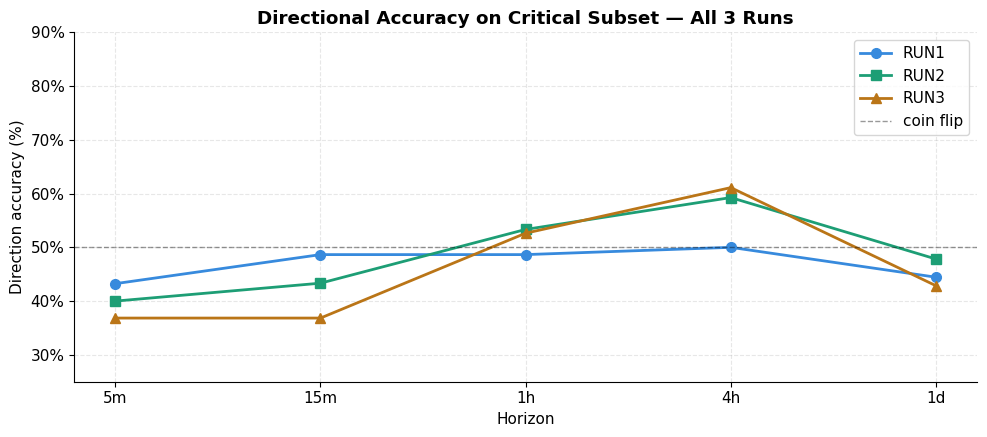

In [18]:
def dir_accuracy(subset, horizon, dir_col):
    s = subset[subset[dir_col].isin(['up','down']) & subset[horizon].notna()]
    if len(s) == 0:
        return np.nan, 0
    actual = s[horizon].apply(lambda x: 'up' if x > 0 else 'down')
    return (actual == s[dir_col]).sum() / len(s), len(s)

rows = []
for tag, crit_col, dir_col in [
    ('RUN1 crit', 'is_critical_r1', 'direction_r1'),
    ('RUN2 crit', 'is_critical_r2', 'direction_r2'),
    ('RUN3 crit', 'is_critical_r3', 'direction_r3'),
    ('RUN1 all',  None,             'direction_r1'),
    ('RUN2 all',  None,             'direction_r2'),
    ('RUN3 all',  None,             'direction_r3'),
]:
    g = base[base[crit_col] == True] if crit_col else base
    row = {'slice': tag, 'n': len(g)}
    for h, hl in zip(HORIZONS, H_LABELS):
        acc, n = dir_accuracy(g, h, dir_col)
        row[hl] = f'{acc*100:.1f}% ({n})' if n else 'n/a'
    rows.append(row)
display(pd.DataFrame(rows).set_index('slice'))

fig, ax = plt.subplots(figsize=(10, 4.5))
for tag, crit_col, dir_col, style in [
    ('RUN1', 'is_critical_r1', 'direction_r1', '-o'),
    ('RUN2', 'is_critical_r2', 'direction_r2', '-s'),
    ('RUN3', 'is_critical_r3', 'direction_r3', '-^'),
]:
    g = base[base[crit_col] == True]
    accs = [dir_accuracy(g, h, dir_col)[0]*100 for h in HORIZONS]
    ax.plot(H_LABELS, accs, style, color=RUN_COLOR[tag], label=tag, linewidth=2, markersize=7)
ax.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='coin flip')
ax.set_ylabel('Direction accuracy (%)'); ax.set_xlabel('Horizon')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(25, 90)
ax.set_title('Directional Accuracy on Critical Subset — All 3 Runs', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 8b — RUN3 Directional Accuracy Deep Dive

Directional accuracy of RUN3 across every horizon (5m, 15m, 1h, 4h, 1d), sliced by criticality, tier, event, and content type. Baseline is a coin flip (50%).


In [19]:
# RUN3 directional accuracy across all horizons, by slice
def dir_acc_row(subset, dir_col='direction_r3'):
    row = {'n': len(subset)}
    for h, hl in zip(HORIZONS, H_LABELS):
        s = subset[subset[dir_col].isin(['up','down']) & subset[h].notna()]
        if len(s) == 0:
            row[hl] = 'n/a'
            continue
        actual = s[h].apply(lambda x: 'up' if x > 0 else 'down')
        acc = (actual == s[dir_col]).sum() / len(s)
        row[hl] = f'{acc*100:.1f}% ({len(s)})'
    return row

slices = {
    'All RUN3 (any dir)':       base,
    'Critical (RUN3)':          base[base['is_critical_r3'] == True],
    'Not critical (RUN3)':      base[base['is_critical_r3'] == False],
    'Tier 1':                   base[base['event_tier_r3'] == 1],
    'Tier 2':                   base[base['event_tier_r3'] == 2],
    'Tier 3':                   base[base['event_tier_r3'] == 3],
    'Tier 4':                   base[base['event_tier_r3'] == 4],
    'Tier 1 critical':          base[(base['event_tier_r3']==1) & (base['is_critical_r3']==True)],
    'NFP / Jobs (ev 10,11)':    base[base['event_number_r3'].isin([10,11])],
    'Trade tariff (ev 19)':     base[base['event_number_r3'] == 19],
    'Fed rate repricing (31)':  base[base['event_number_r3'] == 31],
    'hard_news':                base[base['content_type_r3'] == 'hard_news'],
    'analysis':                 base[base['content_type_r3'] == 'analysis'],
    'table_used = True':        base[base['table_used_r3'] == True],
}

rows = []
for name, grp in slices.items():
    row = {'slice': name}
    row.update(dir_acc_row(grp))
    rows.append(row)
dir_tbl = pd.DataFrame(rows).set_index('slice')
print('RUN3 direction accuracy by horizon and slice:')
display(dir_tbl)


RUN3 direction accuracy by horizon and slice:


,n,5m,15m,1h,4h,1d
slice,,,,,,
All RUN3 (any dir),187,48.9% (88),45.5% (88),48.3% (87),53.0% (83),53.1% (64)
Critical (RUN3),20,36.8% (19),36.8% (19),52.6% (19),61.1% (18),42.9% (14)
Not critical (RUN3),167,52.2% (69),47.8% (69),47.1% (68),50.8% (65),56.0% (50)
Tier 1,47,44.7% (38),44.7% (38),45.9% (37),48.6% (35),42.9% (28)
Tier 2,15,45.5% (11),45.5% (11),45.5% (11),50.0% (10),87.5% (8)
Tier 3,63,46.7% (15),46.7% (15),46.7% (15),50.0% (14),10.0% (10)
Tier 4,40,58.3% (24),45.8% (24),54.2% (24),62.5% (24),77.8% (18)
Tier 1 critical,13,30.8% (13),30.8% (13),61.5% (13),58.3% (12),50.0% (8)
"NFP / Jobs (ev 10,11)",13,58.3% (12),66.7% (12),58.3% (12),66.7% (12),60.0% (5)


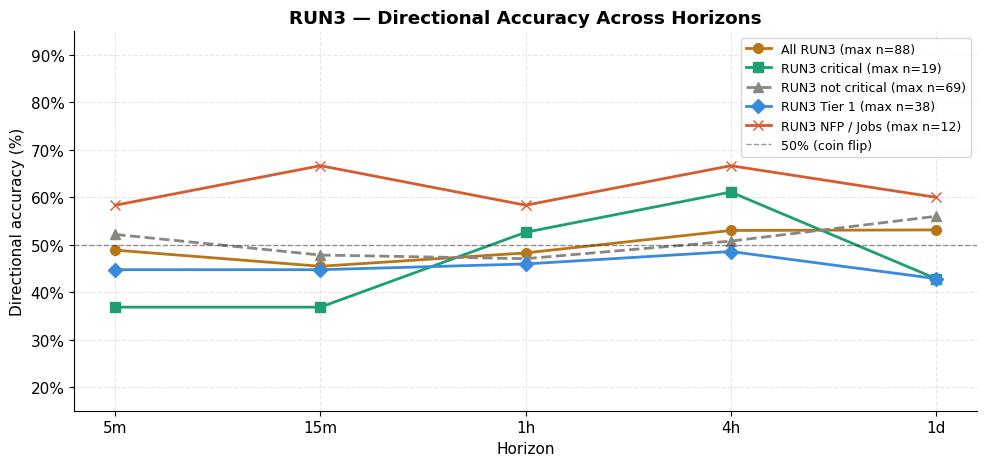

In [20]:
# Chart: RUN3 dir accuracy vs horizon, key slices
key_slices = {
    'All RUN3':              base,
    'RUN3 critical':         base[base['is_critical_r3'] == True],
    'RUN3 not critical':     base[base['is_critical_r3'] == False],
    'RUN3 Tier 1':           base[base['event_tier_r3'] == 1],
    'RUN3 NFP / Jobs':       base[base['event_number_r3'].isin([10,11])],
}
colors = [AMBER, TEAL, GRAY, BLUE, CORAL]
styles = ['-o', '-s', '--^', '-D', '-x']

fig, ax = plt.subplots(figsize=(10, 4.8))
for (name, grp), col, style in zip(key_slices.items(), colors, styles):
    accs, ns = [], []
    for h in HORIZONS:
        s = grp[grp['direction_r3'].isin(['up','down']) & grp[h].notna()]
        if len(s) == 0:
            accs.append(np.nan); ns.append(0)
        else:
            actual = s[h].apply(lambda x: 'up' if x > 0 else 'down')
            accs.append((actual == s['direction_r3']).sum() / len(s) * 100)
            ns.append(len(s))
    label = f'{name} (max n={max(ns)})'
    ax.plot(H_LABELS, accs, style, label=label, color=col, linewidth=2, markersize=7)

ax.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='50% (coin flip)')
ax.set_ylabel('Directional accuracy (%)'); ax.set_xlabel('Horizon')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(15, 95)
ax.set_title('RUN3 — Directional Accuracy Across Horizons', fontweight='bold')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()


In [21]:
# RUN3 confusion by predicted direction at each horizon (critical subset)
crit3 = base[base['is_critical_r3'] == True]
rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    s = crit3[crit3['direction_r3'].isin(['up','down']) & crit3[h].notna()]
    if len(s) == 0:
        continue
    actual = s[h].apply(lambda x: 'up' if x > 0 else 'down')
    up_s = s[s['direction_r3'] == 'up']
    dn_s = s[s['direction_r3'] == 'down']
    def acc(sub):
        if len(sub) == 0: return np.nan, 0
        a = sub[h].apply(lambda x: 'up' if x > 0 else 'down')
        return (a == sub['direction_r3']).sum() / len(sub), len(sub)
    up_acc, up_n = acc(up_s)
    dn_acc, dn_n = acc(dn_s)
    overall = (actual == s['direction_r3']).sum() / len(s)
    rows.append({
        'horizon': hl,
        'n critical w/ dir': len(s),
        'pred up':   f'{up_acc*100:.1f}% ({up_n})' if up_n else 'n/a',
        'pred down': f'{dn_acc*100:.1f}% ({dn_n})' if dn_n else 'n/a',
        'overall':   f'{overall*100:.1f}%',
    })
print('RUN3 critical subset — accuracy by predicted direction:')
display(pd.DataFrame(rows).set_index('horizon'))


RUN3 critical subset — accuracy by predicted direction:


,n critical w/ dir,pred up,pred down,overall
horizon,,,,
5m,19,44.4% (9),30.0% (10),36.8%
15m,19,44.4% (9),30.0% (10),36.8%
1h,19,66.7% (9),40.0% (10),52.6%
4h,18,75.0% (8),50.0% (10),61.1%
1d,14,66.7% (9),0.0% (5),42.9%


## 9 — Headline Numbers

In [22]:
def lift_and_p(df, crit_col, h='pct_15m'):
    c  = df.loc[df[crit_col]==True,  h].abs().dropna()
    nc = df.loc[df[crit_col]==False, h].abs().dropna()
    if len(c) == 0 or len(nc) == 0: return np.nan, np.nan
    _, p = mannwhitneyu(c, nc, alternative='greater')
    return c.mean()/nc.mean(), p

metrics = {}
for tag, crit_col, lvl_col, dir_col in [
    ('RUN1', 'is_critical_r1', 'criticality_level_r1', 'direction_r1'),
    ('RUN2', 'is_critical_r2', 'criticality_level_r2', 'direction_r2'),
    ('RUN3', 'is_critical_r3', 'criticality_level_r3', 'direction_r3'),
]:
    lift, p = lift_and_p(base, crit_col)
    acc, n  = dir_accuracy(base[base[crit_col]==True], 'pct_15m', dir_col)
    pr = prf(base, lvl_col)
    metrics[tag] = {
        'relevant':  int(base[f'is_relevant_{tag[-1].lower()}'.replace("1","r1").replace("2","r2").replace("3","r3")].sum()),
        'critical':  int(base[crit_col].sum()),
        'lift@15m':  f'{lift:.2f}x',
        'MW p@15m':  f'{p:.4f}',
        'dir acc@15m (crit)': f'{acc*100:.1f}% (n={n})' if not np.isnan(acc) else 'n/a',
        'precision': pr['precision'], 'recall': pr['recall'], 'F1': pr['F1'],
    }

# Fix relevant lookup (above string-mangle was brittle — just use explicit cols)
for tag, rel_col in [('RUN1','is_relevant_r1'), ('RUN2','is_relevant_r2'), ('RUN3','is_relevant_r3')]:
    metrics[tag]['relevant'] = int(base[rel_col].sum())

print('=' * 78)
print('  HEADLINE — THREE RUNS ON THE SAME 187 ARTICLES')
print('=' * 78)
display(pd.DataFrame(metrics))

print(f'\nAll 3 flagged critical : {int((base["is_critical_r1"] & base["is_critical_r2"] & base["is_critical_r3"]).sum())}')
print(f'All 3 flagged not crit : {int((~base["is_critical_r1"] & ~base["is_critical_r2"] & ~base["is_critical_r3"]).sum())}')

  HEADLINE — THREE RUNS ON THE SAME 187 ARTICLES


,RUN1,RUN2,RUN3
relevant,187,176,165
critical,39,31,20
lift@15m,2.31x,1.95x,2.56x
MW p@15m,0.0020,0.0161,0.0011
dir acc@15m (crit),48.6% (n=37),43.3% (n=30),36.8% (n=19)
precision,56.8%,56.7%,73.7%
recall,29.6%,25.8%,22.6%
F1,0.389,0.354,0.346



All 3 flagged critical : 17
All 3 flagged not crit : 140


In [23]:
r3[r3['criticality_level'] == 'high']['true_criticality']

2      not high
3          high
12         high
18     not high
26          NaN
33     not high
38     not high
42         high
60         high
61         high
70         high
74     not high
81         high
103        high
105        high
121        high
128        high
137        high
175        high
185        high
Name: true_criticality, dtype: str

In [24]:
print(r3.loc[2]['reasoning'])

Article_timing = 'live_window' (Powell's comments made today post-decision). Content_type = hard_news. FOMC information-content test: article contains new forward guidance (Powell explicitly stating markets should not assume December cut) and dissent votes with direction (Schmid hawkish, Miran dovish). This is the vehicle by which new policy messaging enters the market. Macro regime shows DXY 15m vol threshold at 0.0220%; article reports DXY up 0.63% intraday, well above threshold. Comparable examples (Examples 5, 6, 9) show Hawkish Pivot events with live_window timing and new guidance/dot plot information labeled high despite modest pct_15m moves. Powell's pushback on December cut expectations is primary new information moving markets in real time.


Article_timing = 'live_window' (Powell's comments made today post-decision). Content_type = hard_news. FOMC information-content test: article contains new forward guidance (Powell explicitly stating markets should not assume December cut) and dissent votes with direction (Schmid hawkish, Miran dovish). This is the vehicle by which new policy messaging enters the market. Macro regime shows DXY 15m vol threshold at 0.0220%; article reports DXY up 0.63% intraday, well above threshold. Comparable examples (Examples 5, 6, 9) show Hawkish Pivot events with live_window timing and new guidance/dot plot information labeled high despite modest pct_15m moves. Powell's pushback on December cut expectations is primary new information moving markets in real time.